# Exploración de Sleep-EDFx

Ejecuta las celdas de arriba hacia abajo, o selecciona **Run → Run All Cells**.
Este notebook es autónomo: no ejecuta ni importa el archivo `.py` del proyecto.
Lee EDF locales, sin descargar datos. Termina la descarga antes de interpretar los resultados.

Objetivos: inventario de registros y sujetos, perfil de canales, conteo de épocas de 30 segundos y distribución de estadios.
Fuente: [PhysioNet Sleep-EDFx](https://physionet.org/content/sleep-edfx/1.0.0/).


## 1. Configuración
Abre Jupyter desde la carpeta del proyecto. Si lo abres en otro lugar, ajusta `PROJECT_DIR`.

In [1]:
from pathlib import Path
from collections import defaultdict
import os
import re
import json
import hashlib
from datetime import datetime

PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'data' / 'sleep-edfx'
OUTPUT_DIR = PROJECT_DIR / 'outputs' / 'notebook'
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_DIR / '.cache' / 'matplotlib'))

import mne
import numpy as np
import pandas as pd
import pyedflib
import matplotlib.pyplot as plt
from IPython.display import display

if not DATA_DIR.is_dir():
    raise FileNotFoundError(f'Ajusta PROJECT_DIR: no existe {DATA_DIR}')
print('Datos:', DATA_DIR)
print('Salidas:', OUTPUT_DIR)


Datos: /Users/mijo/Documents/Maestria/Proyecto de grado/data/sleep-edfx
Salidas: /Users/mijo/Documents/Maestria/Proyecto de grado/outputs/notebook


## 2. Inventario local
Se busca recursivamente. Un archivo presente puede estar incompleto si la descarga sigue activa.
SC y ST identifican estudios distintos; las noches de un mismo sujeto no se cuentan como sujetos nuevos.


In [2]:
psg_files = sorted(DATA_DIR.rglob('*-PSG.edf'))
hyp_files = sorted(DATA_DIR.rglob('*-Hypnogram.edf'))
display(pd.DataFrame({'tipo': ['PSG', 'Hipnograma'], 'archivos': [len(psg_files), len(hyp_files)]}))
if not psg_files:
    print('Todavía no hay datos. Las tablas siguientes estarán vacías.')
display(pd.DataFrame({'archivo': [str(p.relative_to(DATA_DIR)) for p in psg_files[:10]]}))


,tipo,archivos
0,PSG,197
1,Hipnograma,197


,archivo
0,sleep-cassette/SC4001E0-PSG.edf
1,sleep-cassette/SC4002E0-PSG.edf
2,sleep-cassette/SC4011E0-PSG.edf
3,sleep-cassette/SC4012E0-PSG.edf
4,sleep-cassette/SC4021E0-PSG.edf
5,sleep-cassette/SC4022E0-PSG.edf
6,sleep-cassette/SC4031E0-PSG.edf
7,sleep-cassette/SC4032E0-PSG.edf
8,sleep-cassette/SC4041E0-PSG.edf
9,sleep-cassette/SC4042E0-PSG.edf


## 3. Etiquetas y reglas de conteo
Se agrupan los estadios originales 3 y 4 como N3; esto no equivale a una nueva evaluación AASM.
M (movimiento) y ? (sin clasificar) se conservan. Los porcentajes incluyen ambas clases.

Se cuentan ventanas completas de 30 s desde el inicio del PSG, alineando fechas de cabecera.
Se excluyen ventanas con huecos, solapamientos, etiquetas desconocidas o transiciones internas.
No se recorta vigilia ni se filtran sujetos. El perfil conserva la frecuencia original por canal.


In [3]:
CLASSES = ['W', 'N1', 'N2', 'N3', 'REM', 'M', '?']
LABEL_MAP = {'Sleep stage W': 'W', 'Sleep stage 1': 'N1',
             'Sleep stage 2': 'N2', 'Sleep stage 3': 'N3',
             'Sleep stage 4': 'N3', 'Sleep stage R': 'REM',
             'Movement time': 'M', 'Sleep stage ?': '?'}
LABEL_MAP.update({x: x for x in CLASSES})
LABEL_MAP.update({'1': 'N1', '2': 'N2', '3': 'N3', '4': 'N3', 'R': 'REM'})


def identity(path):
    match = re.fullmatch(r'((SC4|ST7)\d{2}[12][A-Za-z0-9])[A-Za-z0-9]-(PSG|Hypnogram)\.edf', path.name)
    if not match:
        raise ValueError('Nombre no reconocido como Sleep-EDFx')
    record = match[1]
    return record, record[:5], record[:2]


def epoch_labels(annotations, duration, offset=0):
    """Cuenta solo ventanas completas en la grilla de 30 s del PSG.

    Huecos, transiciones dentro de una época y solapamientos son excluidos;
    '?' es una etiqueta explícita y no se usa para rellenar datos faltantes.
    """
    starts = np.arange(int(np.floor(duration / 30))) * 30.0
    labels = np.full(len(starts), '', dtype=object)
    touches = np.zeros(len(starts), dtype=int)
    unknown = set()
    for onset, length, description in zip(annotations.onset, annotations.duration, annotations.description):
        begin, end = float(onset) + offset, float(onset) + offset + float(length)
        if length <= 0:
            continue
        intersects = (starts < end - 1e-6) & (starts + 30 > begin + 1e-6)
        touches[intersects] += 1
        full = (starts >= begin - 1e-6) & (starts + 30 <= end + 1e-6)
        mapped = LABEL_MAP.get(str(description).strip())
        if mapped is None:
            unknown.add(str(description))
        else:
            labels[full] = mapped
    labels[touches != 1] = ''
    counts = {label: int(np.sum(labels == label)) for label in CLASSES}
    return counts, int(np.sum(labels == '')), sorted(unknown)



def read_annotation_header(path):
    """Fecha/hora de campos EDF fijos, sin exigir el texto Recordingfield.

    Sleep-EDFx contiene siete hipnogramas con Startdate textual del día anterior.
    No se cambia el archivo: se contrasta el inicio fijo con el PSG y se audita.
    """
    with path.open('rb') as stream:
        header = stream.read(256)
    if len(header) != 256 or header[:8].strip() != b'0':
        raise ValueError('Cabecera EDF inválida')
    date = header[168:176].decode('ascii')
    time = header[176:184].decode('ascii')
    day, month, year = map(int, date.split('.'))
    hour, minute, second = map(int, time.split('.'))
    year += 1900 if year >= 85 else 2000
    start = datetime(year, month, day, hour, minute, second)
    recording = header[88:168].decode('ascii').strip()
    return start, recording


def annotation_coverage(annotations, duration, offset=0):
    starts = np.arange(int(duration // 30)) * 30.0
    touched = np.zeros(len(starts), dtype=bool)
    for onset, length in zip(annotations.onset, annotations.duration):
        if length > 0:
            touched |= (starts < onset + offset + length - 1e-6) & (starts + 30 > onset + offset + 1e-6)
    return int((~touched).sum())


In [4]:
display(pd.DataFrame(list(LABEL_MAP.items())[:8], columns=['etiqueta_original', 'clase']))

,etiqueta_original,clase
0,Sleep stage W,W
1,Sleep stage 1,N1
2,Sleep stage 2,N2
3,Sleep stage 3,N3
4,Sleep stage 4,N3
5,Sleep stage R,REM
6,Movement time,M
7,Sleep stage ?,?


## 4. Procesamiento de cabeceras e hipnogramas
Emparejamos por los siete primeros caracteres del nombre oficial; el octavo puede cambiar.
Las parejas duplicadas, incompletas y los errores de lectura se reportan. No se cargan las señales completas.

**Corrección de lectura:** la fecha y hora fijas del EDF del hipnograma se contrastan con el PSG. El campo textual `Recordingfield` presenta una fecha distinta en siete archivos originales; se conserva en `header_audit` y no se alteran los EDF. MNE lee las anotaciones y pyEDFlib conserva el perfil original de los canales PSG.


In [5]:
def explore(data_dir, output_dir):
    if not data_dir.is_dir():
        raise ValueError(f'No existe la carpeta de datos: {data_dir}')
    groups = defaultdict(lambda: {'PSG': [], 'Hypnogram': []})
    issues, channels, records, distributions, header_audit = [], [], [], [], []
    files = {kind: sorted(data_dir.rglob(f'*-{kind}.edf')) for kind in ('PSG', 'Hypnogram')}
    subjects = set()
    def issue(record, message):
        issues.append({'record_id': record, 'issue': message})
    for kind, paths in files.items():
        for path in paths:
            try:
                record, subject, subset = identity(path)
                groups[record][kind].append(path)
                if kind == 'PSG':
                    subjects.add(subject)
            except ValueError as exc:
                issue(str(path), str(exc))
    pair_count = 0
    for record, pair in sorted(groups.items()):
        if len(pair['PSG']) != 1 or len(pair['Hypnogram']) != 1:
            issue(record, f"Pareja incompleta o ambigua: {len(pair['PSG'])} PSG, {len(pair['Hypnogram'])} hipnogramas")
            continue
        pair_count += 1
        psg, hyp = pair['PSG'][0], pair['Hypnogram'][0]
        try:
            with pyedflib.EdfReader(str(psg)) as reader:
                duration = float(reader.file_duration)
                start = reader.getStartdatetime()
                headers = reader.getSignalHeaders()
            hyp_start, recording_field = read_annotation_header(hyp)
            parts = recording_field.split()
            textual_date = datetime.strptime(parts[1], '%d-%b-%Y').date() if len(parts) > 1 and parts[0] == 'Startdate' and parts[1] != 'X' else None
            header_audit.append({'record_id': record, 'psg_start': start.isoformat(),
                                 'hyp_fixed_start': hyp_start.isoformat(),
                                 'hyp_recording_field': recording_field,
                                 'text_date_mismatch': textual_date is not None and textual_date != hyp_start.date()})
            offset = (hyp_start - start).total_seconds()
            annotations = mne.read_annotations(str(hyp))
            counts, excluded, unknown = epoch_labels(annotations, duration, offset)
            if offset:
                issue(record, f'Desfase hipnograma–PSG: {offset} s; corregido por cabeceras')
            uncovered = annotation_coverage(annotations, duration, offset)
            if excluded:
                issue(record, f'{uncovered} épocas sin cobertura del hipnograma; {excluded - uncovered} excluidas por otras causas')
            if unknown:
                issue(record, 'Etiquetas no reconocidas: ' + ', '.join(unknown))
            row = {'record_id': record, 'subject_id': record[:5], 'subset': record[:2],
                   'psg': str(psg), 'hypnogram': str(hyp), 'duration_s': duration,
                   'n_epochs_signal': int(duration // 30), 'n_epochs_labeled': sum(counts.values()),
                   'n_epochs_excluded': excluded, 'n_epochs_uncovered': uncovered, 'trailing_seconds': duration % 30,
                   'n_channels': len(headers)}
            records.append(row)
            for header in headers:
                channels.append({'record_id': record, 'channel': header['label'],
                                 'sfreq_hz': header['sample_frequency'], 'unit': header['dimension']})
            for label, count in counts.items():
                distributions.append({'record_id': record, 'subject_id': record[:5],
                                      'subset': record[:2], 'class': label, 'n_epochs': count})
        except Exception as exc:
            issue(record, f'Error de lectura: {type(exc).__name__}: {exc}')
    total_counts = {label: sum(row['n_epochs'] for row in distributions if row['class'] == label) for label in CLASSES}
    total = sum(total_counts.values())
    table = pd.DataFrame([{'class': label, 'n_epochs': count,
                           'percentage': 100 * count / total if total else 0.0}
                          for label, count in total_counts.items()])
    summary = {'data_dir': str(data_dir), 'n_psg_files': len(files['PSG']),
               'n_hypnogram_files': len(files['Hypnogram']), 'n_subjects_found': len(subjects),
               'n_record_ids_found': sum(bool(pair['PSG']) for pair in groups.values()),
               'n_pairs': pair_count, 'n_records_processed': len(records),
               'n_subjects_processed': len({row['subject_id'] for row in records}),
               'n_epochs_signal': sum(row['n_epochs_signal'] for row in records),
               'n_epochs_labeled': total,
               'n_epochs_excluded': sum(row['n_epochs_excluded'] for row in records),
               'n_epochs_uncovered': sum(row['n_epochs_uncovered'] for row in records),
               'n_hyp_header_date_mismatch': sum(row['text_date_mismatch'] for row in header_audit),
               'n_issues': len(issues)}
    frames = {'class_distribution': table,
              'records': pd.DataFrame(records, columns=['record_id', 'subject_id', 'subset', 'psg', 'hypnogram', 'duration_s', 'n_epochs_signal', 'n_epochs_labeled', 'n_epochs_excluded', 'n_epochs_uncovered', 'trailing_seconds', 'n_channels']),
              'channels': pd.DataFrame(channels, columns=['record_id', 'channel', 'sfreq_hz', 'unit']),
              'classes_by_record': pd.DataFrame(distributions, columns=['record_id', 'subject_id', 'subset', 'class', 'n_epochs']),
              'issues': pd.DataFrame(issues, columns=['record_id', 'issue']),
              'header_audit': pd.DataFrame(header_audit)}
    return summary, frames


In [6]:
summary, frames = explore(DATA_DIR, OUTPUT_DIR)
records = frames['records']
channels = frames['channels']
classes = frames['class_distribution']
by_record = frames['classes_by_record']
issues = frames['issues']
display(pd.Series(summary, name='valor').to_frame())


,valor
data_dir,/Users/mijo/Documents/Maestria/Proyecto de gra...
n_psg_files,197
n_hypnogram_files,197
n_subjects_found,100
n_record_ids_found,197
n_pairs,197
n_records_processed,197
n_subjects_processed,100
n_epochs_signal,461870
n_epochs_labeled,459198


## 5. Registros, sujetos y duración
Los totales procesados solo incluyen parejas leídas con éxito.

,record_id,subject_id,subset,psg,hypnogram,duration_s,n_epochs_signal,n_epochs_labeled,n_epochs_excluded,n_epochs_uncovered,trailing_seconds,n_channels
0,SC4001E,SC400,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,79500.0,2650,2650,0,0,0.0,7
1,SC4002E,SC400,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,84900.0,2830,2830,0,0,0.0,7
2,SC4011E,SC401,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,84060.0,2802,2802,0,0,0.0,7
3,SC4012E,SC401,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,85500.0,2850,2850,0,0,0.0,7
4,SC4021E,SC402,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,84120.0,2804,2804,0,0,0.0,7
5,SC4022E,SC402,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,82680.0,2756,2756,0,0,0.0,7
6,SC4031E,SC403,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,84600.0,2820,2820,0,0,0.0,7
7,SC4032E,SC403,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,81960.0,2732,2732,0,0,0.0,7
8,SC4041E,SC404,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,77100.0,2570,2570,0,0,0.0,7
9,SC4042E,SC404,SC,/Users/mijo/Documents/Maestria/Proyecto de gra...,/Users/mijo/Documents/Maestria/Proyecto de gra...,83760.0,2792,2792,0,0,0.0,7


,registros,sujetos,epocas
subset,,,
SC,153,78,416424
ST,44,22,42774


,duracion_horas
count,197.000000
mean,19.538254
std,5.964451
min,7.494444
25%,20.016667
50%,22.683333
75%,23.250000
max,24.000000


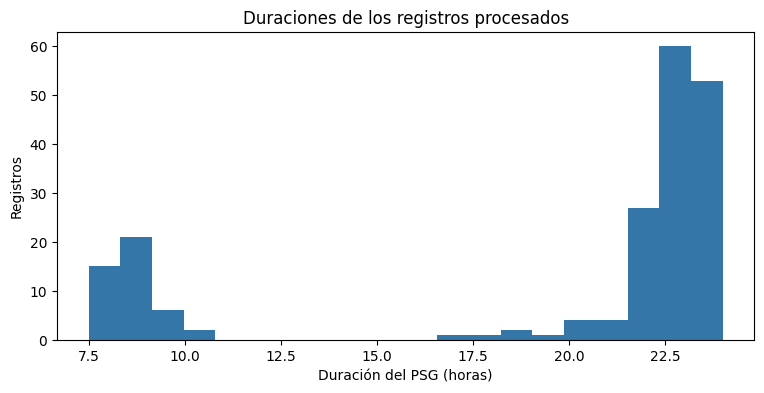

In [7]:
display(records.head(10))
if not records.empty:
    display(records.groupby('subset').agg(registros=('record_id', 'nunique'), sujetos=('subject_id', 'nunique'), epocas=('n_epochs_labeled', 'sum')))
    display((records['duration_s'] / 3600).describe().rename('duracion_horas').to_frame())
    ax = (records['duration_s'] / 3600).plot.hist(bins=20, figsize=(9, 4), color='#3576A8')
    ax.set(xlabel='Duración del PSG (horas)', ylabel='Registros', title='Duraciones de los registros procesados')
    plt.show()


## 6. Canales y frecuencias de muestreo
La presencia se calcula sobre los registros procesados; un canal opcional ausente no implica un error.

In [8]:
if not channels.empty:
    channel_profile = channels.groupby(['channel', 'sfreq_hz', 'unit'], dropna=False).agg(registros=('record_id', 'nunique')).reset_index()
    channel_profile['presencia_porcentaje'] = 100 * channel_profile['registros'] / len(records)
    display(channel_profile)
    presence = pd.crosstab(channels['record_id'], channels['channel']).gt(0)
    display(presence.head(10))
else:
    channel_profile = pd.DataFrame(columns=['channel', 'sfreq_hz', 'unit', 'registros', 'presencia_porcentaje'])
    print('No hay canales procesados.')


,channel,sfreq_hz,unit,registros,presencia_porcentaje
0,EEG Fpz-Cz,100.0,uV,197,100.000000
1,EEG Pz-Oz,100.0,uV,197,100.000000
2,EMG submental,1.0,uV,153,77.664975
3,EMG submental,100.0,uV,44,22.335025
4,EOG horizontal,100.0,uV,197,100.000000
5,Event marker,1.0,,153,77.664975
6,Marker,10.0,ID+M-E,44,22.335025
7,Resp oro-nasal,1.0,,153,77.664975
8,Temp rectal,1.0,,68,34.517766
9,Temp rectal,1.0,DegC,85,43.147208


channel,EEG Fpz-Cz,EEG Pz-Oz,EMG submental,EOG horizontal,Event marker,Marker,Resp oro-nasal,Temp rectal
record_id,,,,,,,,
SC4001E,True,True,True,True,True,False,True,True
SC4002E,True,True,True,True,True,False,True,True
SC4011E,True,True,True,True,True,False,True,True
SC4012E,True,True,True,True,True,False,True,True
SC4021E,True,True,True,True,True,False,True,True
SC4022E,True,True,True,True,True,False,True,True
SC4031E,True,True,True,True,True,False,True,True
SC4032E,True,True,True,True,True,False,True,True
SC4041E,True,True,True,True,True,False,True,True


## 7. Distribución de clases
El denominador es el total de épocas etiquetadas aceptadas, incluyendo M y ?. No incluye épocas excluidas.

Razón mayor/menor entre los cinco estadios presentes: 14.90
Clases ausentes: []


,class,n_epochs,percentage
0,W,289856,63.12
1,N1,25175,5.48
2,N2,88983,19.38
3,N3,19454,4.24
4,REM,34184,7.44
5,M,211,0.05
6,?,1335,0.29


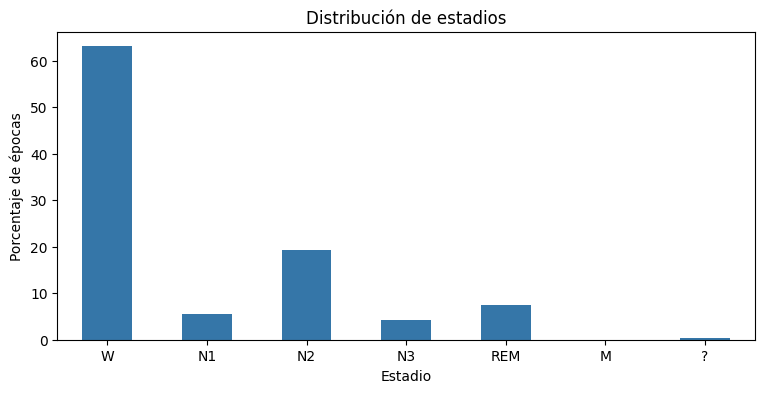

In [9]:
display(classes.round({'percentage': 2}))
if classes['n_epochs'].sum():
    ax = classes.plot.bar(x='class', y='percentage', legend=False, color='#3576A8', figsize=(9, 4), rot=0)
    ax.set(xlabel='Estadio', ylabel='Porcentaje de épocas', title='Distribución de estadios')
    plt.show()
    positive = classes.loc[classes['class'].isin(['W', 'N1', 'N2', 'N3', 'REM']) & (classes['n_epochs'] > 0), 'n_epochs']
    print(f'Razón mayor/menor entre los cinco estadios presentes: {positive.max() / positive.min():.2f}')
    print('Clases ausentes:', classes.loc[classes['n_epochs'] == 0, 'class'].tolist())


## 8. Variación entre estudios y sujetos
Cada fila se normaliza por sus propias épocas aceptadas.

class,W,N1,N2,N3,REM,M,?
subset,,,,,,,
SC,68.54,5.17,16.60,3.13,6.20,0.03,0.32
ST,10.34,8.54,46.41,15.00,19.52,0.19,0.00


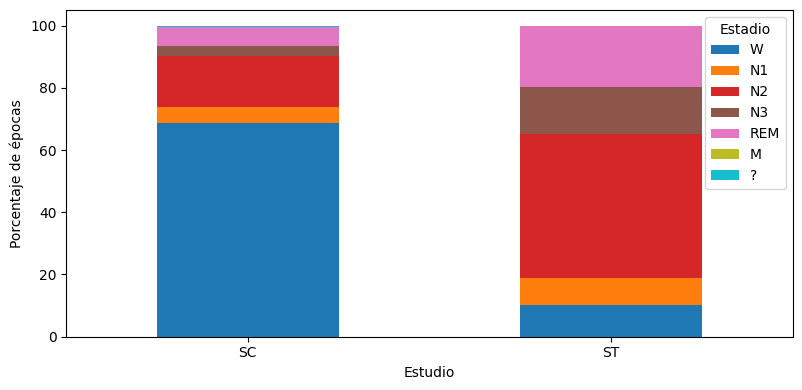

class,W,N1,N2,N3,REM,M,?
subject_id,,,,,,,
SC400,70.84,2.14,11.37,9.43,6.20,0.02,0.00
SC401,65.11,3.56,21.62,3.56,6.12,0.00,0.04
SC402,67.95,5.00,17.03,3.85,6.15,0.02,0.00
SC403,71.42,1.91,15.94,3.39,7.35,0.00,0.00
SC404,61.67,5.65,21.15,2.74,8.69,0.09,0.00
...,...,...,...,...,...,...,...
ST719,4.88,4.72,51.33,16.17,22.91,0.00,0.00
ST720,2.03,5.65,67.75,7.46,16.90,0.22,0.00
ST721,15.67,9.34,43.89,16.72,14.37,0.00,0.00


In [10]:
for dimension in ['subset', 'subject_id']:
    if not by_record.empty:
        counts = by_record.pivot_table(index=dimension, columns='class', values='n_epochs', aggfunc='sum', fill_value=0).reindex(columns=CLASSES, fill_value=0)
        percentages = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
        display(percentages.round(2))
        if dimension == 'subset':
            percentages.plot.bar(stacked=True, figsize=(9, 4), rot=0, colormap='tab10')
            plt.ylabel('Porcentaje de épocas')
            plt.xlabel('Estudio')
            plt.legend(title='Estadio', bbox_to_anchor=(1, 1))
            plt.tight_layout()
            plt.show()


## 9. Incidencias y límites
Revisa esta tabla antes de usar los resultados en la propuesta. Esta exploración no evalúa artefactos ni calidad clínica de las señales.

In [11]:
display(issues)
if not records.empty:
    display(records[['record_id', 'n_epochs_signal', 'n_epochs_labeled', 'n_epochs_excluded', 'trailing_seconds']])
    assert (records.n_epochs_signal == records.n_epochs_labeled + records.n_epochs_excluded).all()
    assert int(classes.n_epochs.sum()) == int(records.n_epochs_labeled.sum())
    print('Conteos consistentes.')

    assert (records.n_epochs_excluded == records.n_epochs_uncovered).all(), 'Revisar exclusiones distintas a falta de cobertura'
    # Comprobación independiente: duración anotada recortada al PSG / 30.
    # Es válida aquí porque se verifica que todos los límites caen en la grilla.
    for row in records.itertuples():
        ann = mne.read_annotations(row.hypnogram)
        assert np.allclose(ann.onset / 30, np.round(ann.onset / 30))
        assert np.allclose(ann.duration / 30, np.round(ann.duration / 30))
        assert np.all(ann.onset[1:] >= ann.onset[:-1] + ann.duration[:-1])
        clipped = np.maximum(0, np.minimum(ann.onset + ann.duration, row.n_epochs_signal * 30) - np.maximum(ann.onset, 0))
        assert int(round(clipped.sum() / 30)) == row.n_epochs_labeled
    print('Conteos verificados además por duraciones anotadas, sin solapamientos.')
display(frames['header_audit'].query('text_date_mismatch'))


Conteos consistentes.
Conteos verificados además por duraciones anotadas, sin solapamientos.


,record_id,issue
0,ST7011J,104 épocas sin cobertura del hipnograma; 0 exc...
1,ST7012J,4 épocas sin cobertura del hipnograma; 0 exclu...
2,ST7021J,100 épocas sin cobertura del hipnograma; 0 exc...
3,ST7022J,81 épocas sin cobertura del hipnograma; 0 excl...
4,ST7041J,30 épocas sin cobertura del hipnograma; 0 excl...
5,ST7042J,26 épocas sin cobertura del hipnograma; 0 excl...
6,ST7051J,55 épocas sin cobertura del hipnograma; 0 excl...
7,ST7052J,60 épocas sin cobertura del hipnograma; 0 excl...
8,ST7061J,77 épocas sin cobertura del hipnograma; 0 excl...
9,ST7062J,140 épocas sin cobertura del hipnograma; 0 exc...


,record_id,n_epochs_signal,n_epochs_labeled,n_epochs_excluded,trailing_seconds
0,SC4001E,2650,2650,0,0.0
1,SC4002E,2830,2830,0,0.0
2,SC4011E,2802,2802,0,0.0
3,SC4012E,2850,2850,0,0.0
4,SC4021E,2804,2804,0,0.0
...,...,...,...,...,...
192,ST7212J,1054,1010,44,0.0
193,ST7221J,1098,1033,65,20.0
194,ST7222J,958,951,7,0.0
195,ST7241J,1087,1024,63,0.0


,record_id,psg_start,hyp_fixed_start,hyp_recording_field,text_date_mismatch
155,ST7021J,1994-09-20T00:00:30,1994-09-20T00:00:30,Startdate 19-SEP-1994 X X X,True
163,ST7071J,1994-07-26T00:01:30,1994-07-26T00:01:30,Startdate 25-JUL-1994 X X X,True
168,ST7092J,1994-08-23T00:29:30,1994-08-23T00:29:30,Startdate 22-AUG-1994 X X X,True
175,ST7131J,1994-08-02T00:37:30,1994-08-02T00:37:30,Startdate 01-AUG-1994 X X X,True
176,ST7132J,1994-08-09T00:31:00,1994-08-09T00:31:00,Startdate 08-AUG-1994 X X X,True
177,ST7141J,1994-08-02T00:39:00,1994-08-02T00:39:00,Startdate 01-AUG-1994 X X X,True
178,ST7142J,1994-09-06T00:51:30,1994-09-06T00:51:30,Startdate 05-SEP-1994 X X X,True


### Integridad de los archivos
Se compara cada EDF con el manifiesto oficial descargado. Puede tardar varios segundos.

In [12]:
# Comparación con el manifiesto SHA-256 distribuido con Sleep-EDFx.
# Lee todos los EDF por bloques; no carga el dataset entero en memoria.
manifest = DATA_DIR / 'SHA256SUMS.txt'
integrity_rows = []
if not manifest.exists():
    raise FileNotFoundError('Falta SHA256SUMS.txt: no se puede afirmar integridad de la descarga.')
for line in manifest.read_text().splitlines():
    expected, relative = line.split(maxsplit=1)
    relative = relative.lstrip('*')
    if not relative.endswith('.edf'):
        continue
    path = DATA_DIR / relative
    digest = hashlib.sha256()
    if path.exists():
        with path.open('rb') as stream:
            for block in iter(lambda: stream.read(4 * 1024 * 1024), b''):
                digest.update(block)
    integrity_rows.append({'file': relative, 'exists': path.exists(), 'sha256_ok': path.exists() and digest.hexdigest() == expected})
frames['integrity'] = pd.DataFrame(integrity_rows)
assert len(integrity_rows) > 0
assert frames['integrity']['sha256_ok'].all(), 'Hay archivos ausentes o distintos del manifiesto.'
summary['n_edf_sha256_verified'] = len(integrity_rows)
print(f"Integridad verificada: {len(integrity_rows)} EDF coinciden con el manifiesto local.")


Integridad verificada: 394 EDF coinciden con el manifiesto local.


### Conjunto candidato de seis clases
IBIO contempla W, N1, N2, N3 y REM más M. Se excluye ? del conjunto supervisado, conservándola en la exploración. Aún no se aplican recorte de vigilia, filtros de señal ni particiones.

In [13]:
model_classes = ['W', 'N1', 'N2', 'N3', 'REM', 'M']
model_distribution = classes[classes['class'].isin(model_classes)].copy()
model_total = int(model_distribution.n_epochs.sum())
model_distribution['percentage'] = 100 * model_distribution.n_epochs / model_total if model_total else 0.0
display(model_distribution.round({'percentage': 3}))
print('Épocas candidatas para seis clases, antes de otros filtros:', model_total)
print('Sin anotación no equivale a etiqueta explícita ?. No se imputan etiquetas.')


Épocas candidatas para seis clases, antes de otros filtros: 457863
Sin anotación no equivale a etiqueta explícita ?. No se imputan etiquetas.


,class,n_epochs,percentage
0,W,289856,63.306
1,N1,25175,5.498
2,N2,88983,19.434
3,N3,19454,4.249
4,REM,34184,7.466
5,M,211,0.046


## 10. Exportar resultados
Esta celda guarda las tablas en `outputs/notebook` y reemplaza las salidas previas con los mismos nombres.

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
export_tables = {**frames, 'channel_profile': channel_profile, 'model_distribution': model_distribution}
for name, frame in export_tables.items():
    frame.to_csv(OUTPUT_DIR / f'{name}.csv', index=False)
with pd.ExcelWriter(OUTPUT_DIR / 'exploracion_sleep_edfx.xlsx', engine='openpyxl') as writer:
    for name, frame in export_tables.items():
        frame.to_excel(writer, sheet_name=name[:31], index=False)
(OUTPUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print('Resultados guardados en', OUTPUT_DIR)


Resultados guardados en /Users/mijo/Documents/Maestria/Proyecto de grado/outputs/notebook


## 11. Resultados verificados para la propuesta

Se realizó una exploración reproducible de Sleep-EDF Expanded (Sleep-EDFx), disponible en PhysioNet, mediante un notebook en Python. Se identificaron 394 archivos EDF, organizados en 197 parejas PSG–hipnograma, correspondientes a 100 sujetos. Sleep Cassette (SC) aporta 306 archivos, equivalentes a 153 registros de 78 sujetos, y Sleep Telemetry (ST) aporta 88 archivos, equivalentes a 44 registros de 22 sujetos. Cada registro comprende un archivo PSG con las señales fisiológicas y un hipnograma con las anotaciones de los estadios del sueño. La integridad de los 394 archivos EDF se verificó mediante comparación SHA-256 con el manifiesto distribuido con la base.

Los dos canales EEG (Fpz-Cz y Pz-Oz) y el EOG horizontal están presentes en todos los registros y tienen una frecuencia de muestreo de 100 Hz. Por tanto, una época de 30 segundos contiene 3.000 muestras por canal EEG. El EMG submental presenta diferencias entre estudios: 1 Hz en SC y 100 Hz en ST. En SC corresponde a una envolvente de actividad muscular; por ello, su incorporación requerirá un tratamiento específico y no se asumirá equivalencia directa con el EMG de ST.

Las anotaciones originales siguen la nomenclatura de Rechtschaffen y Kales. Para el análisis se mapearon los estadios 1 y 2 a N1 y N2, se agruparon 3 y 4 como N3 y se convirtió R en REM, conservando W, M y ?. Esta agrupación no constituye una nueva estadificación bajo criterios AASM.

Se contabilizaron 461.870 ventanas completas de 30 segundos dentro de las señales. De ellas, 459.198 cuentan con una anotación válida que cubre toda la ventana; las 2.672 restantes (0,58 %) carecen de cobertura del hipnograma y pertenecen a ST. Estas ventanas se excluyen del conjunto supervisado y se distinguen de las 1.335 épocas etiquetadas explícitamente como ?. La distribución de las épocas anotadas, antes de recortar vigilia o aplicar otros filtros, fue:

| Clase | Número de épocas | Porcentaje |
|---|---:|---:|
| W | 289.856 | 63,122 % |
| N1 | 25.175 | 5,482 % |
| N2 | 88.983 | 19,378 % |
| N3 | 19.454 | 4,237 % |
| REM | 34.184 | 7,444 % |
| M | 211 | 0,046 % |
| ? | 1.335 | 0,291 % |
| **Total** | **459.198** | **100,000 %** |

Se observó un desbalance marcado: W concentra el 63,12 % de las épocas y M representa apenas el 0,046 %. La proporción de vigilia también difiere entre estudios: 68,54 % en SC y 10,34 % en ST. Estas cifras describen los registros completos y no deben interpretarse como la distribución de una noche de sueño previamente delimitada. Se evaluará una regla explícita de recorte de vigilia y se documentará su efecto sobre el tamaño y la distribución del conjunto utilizado para modelar.

Durante la lectura se detectaron siete hipnogramas con discrepancias entre la fecha textual del campo de identificación del registro y su fecha fija de cabecera. Se resolvió la incompatibilidad de lectura utilizando la fecha y hora fijas, que coinciden con las del PSG correspondiente, y se conservaron los archivos originales. Así fue posible procesar los 197 registros. La exploración verificó estructura, canales, integridad y cobertura de etiquetas; aún no comprende una evaluación sistemática de artefactos o calidad de las señales.

De acuerdo con el alcance de IBIO, se conservarán las cinco clases principales y la clase adicional M, excluyendo ? del conjunto supervisado. Esto deja 457.863 épocas candidatas, antes de otros criterios de preparación. Las particiones de entrenamiento, validación y prueba se realizarán por sujeto. Se reportarán F1 macro y métricas por clase, y cualquier estrategia de balanceo se aplicará exclusivamente al entrenamiento. La escasa representación de M deberá considerarse en la evaluación y en la interpretación de los resultados.

Fuente de la base y sus características: [PhysioNet, Sleep-EDF Expanded](https://physionet.org/content/sleep-edfx/1.0.0/). Los conteos y porcentajes corresponden a la exploración local revisada.


### Registro de revisión
- Se preservó la versión previa y sus resultados en `backups/revision_2026-09-19/`.
- Se corrigió la lectura de los siete hipnogramas rechazados por pyEDFlib sin modificar los datos.
- Se separaron ventanas sin cobertura y etiquetas explícitas ?.
- Se verificaron los conteos de forma independiente mediante las duraciones de anotaciones, comprobando límites de 30 s y ausencia de solapamientos.
- Los resultados vigentes están en `outputs/notebook/`. Los resultados anteriores de 190 registros quedan superados.
